# Imports

In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
import time
from sklearn import metrics
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans

In [2]:
df_train = pd.read_csv("dados/nba_treino.csv")
df_test = pd.read_csv("dados/nba_teste.csv")

target_column = 'TARGET_5Yrs'

X_train = df_train.drop(columns=target_column)
X_test = df_test.drop(columns=target_column)
y_train = df_train[target_column]
y_test = df_test[target_column]

# KNN

## Definições de função

In [3]:
def euclidian_distance(p1, p2):
    array1 = np.array(p1)
    array2 = np.array(p2)

    return np.sqrt(np.sum((array1 - array2)**2))

def sort_by_distance(center, df, labels):
    dists_and_labels = [] 
    
    for i, point in enumerate(df.to_numpy()):
        dist = euclidian_distance(center, point)
        dists_and_labels.append((dist, labels[i])) # o primeiro elemento é a distância entre o ponto e center, o segundo é a label do ponto

    dists_and_labels.sort(key=lambda x: x[0])

    labels_sorted = pd.DataFrame([ l[1] for l in dists_and_labels ]) # só as labels, sem a distância

    return labels_sorted

def knn_point(X_train, y_train, point, k):
    labels_by_dist = sort_by_distance(point, X_train, y_train)
    neighbors = labels_by_dist[:k]

    neighbor_targets = neighbors.value_counts() # o número de ocorrências de cada classe em neighbors

    return neighbor_targets.nlargest(1).index[0][0] # a classe de maior ocorrência

def knn_dataset(X_train, y_train, X_test, k):
    start = time.time()

    predictions = X_test.apply(lambda x: knn_point(X_train, y_train, x, k), axis=1)

    end = time.time()
    time_elapsed = round(end-start, 2)
    
    print("KNN feito em", time_elapsed, "segundos!")

    return predictions

def plot_confusion_matrix(y_test, y_predicted_original, y_predicted_scikit, k):
    fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(10,4))
                                   
    sns.heatmap(data=metrics.confusion_matrix(y_test, y_predicted_original), annot=True, ax=ax1)
    ax1.set(xlabel = "Valor Previsto",
        ylabel = "Valor Real",
        title = "Original")
    
    sns.heatmap(data=metrics.confusion_matrix(y_test, y_predicted_scikit), annot=True, ax=ax2)
    ax2.set(xlabel = "Valor Previsto",
        ylabel = "Valor Real",
        title = "Scikit")

    fig.suptitle(f"Matrizes de Confusão (k = {k})")
    plt.savefig(f"plots/knn_confusion_k_{k}.png")
    plt.show()

def plot_knn_scores(y_test, y_predicted_original, y_predicted_scikit, k):
    metrics_to_calc = {
        "Acurácia": metrics.accuracy_score,
        "Precisão": metrics.precision_score,
        "Recall": metrics.recall_score,
        "F1": metrics.f1_score,
    }

    # gera uma lista com os scores
    data_list = []
    for metric_name, funct in metrics_to_calc.items():
        score_original = round(funct(y_test, y_predicted_original), 2)
        score_scikit = round(funct(y_test, y_predicted_scikit), 2)

        data_list.append(
            {
                "Métrica": metric_name,
                "Versão": "Original",
                "Valor": score_original,
            }
        )
        data_list.append(
            {"Métrica": metric_name, "Versão": "Scikit", "Valor": score_scikit}
        )

    df_metrics = pd.DataFrame(data_list)

    # criando os subplots
    metrics_list = list(metrics_to_calc.keys())
    metrics_left = metrics_list[:2]
    metrics_right = metrics_list[2:]

    fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 4), sharex=True)


    # metricas da coluna 1
    df_left = df_metrics[df_metrics["Métrica"].isin(metrics_left)]
    sns.barplot(
        data=df_left, x="Valor", y="Métrica", hue="Versão", ax=ax1, orient="h", palette='viridis'
    )
    ax1.set_xlabel("Score")
    ax1.set_ylabel("")
    ax1.set_xlim(0, 1.15)  # Leave room for labels

    for container in ax1.containers:
        ax1.bar_label(container, fmt="%.2f", padding=5)


    # metricas da coluna 2
    df_right = df_metrics[df_metrics["Métrica"].isin(metrics_right)]
    sns.barplot(
        data=df_right, x="Valor", y="Métrica", hue="Versão", ax=ax2, orient="h", palette='viridis'
    )
    ax2.set_xlabel("Score")
    ax2.set_ylabel("")

    for container in ax2.containers:
        ax2.bar_label(container, fmt="%.2f", padding=5)


    fig.suptitle(f"Comparação de Métricas: Original vs. Scikit (k = {k})", fontsize=14)
    plt.tight_layout()

    plt.savefig(f"plots/knn_scores_k_{k}.png")
    plt.show()


    plot_confusion_matrix(y_test, y_predicted_original, y_predicted_scikit, k)

## Previsão e estatísticas


-----------------------------
(KNN) k atual: 2
-----------------------------

KNN feito em 12.55 segundos!


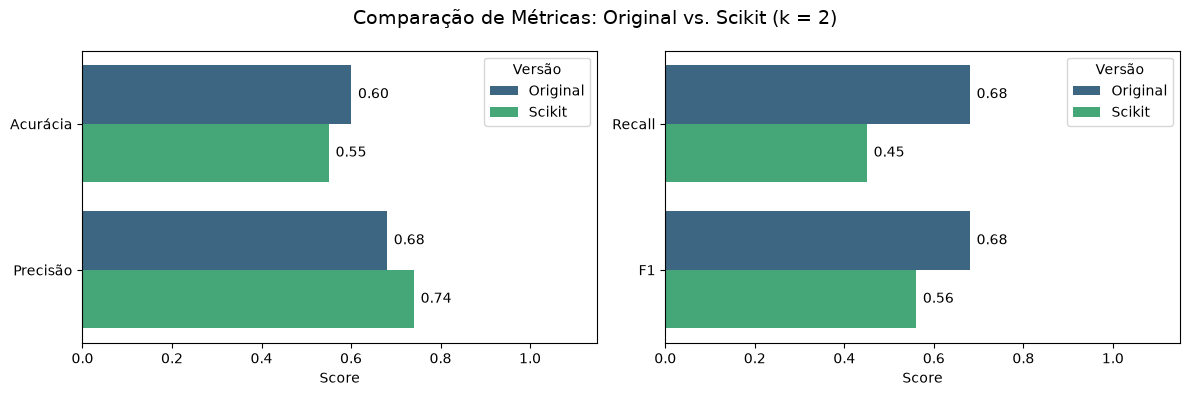

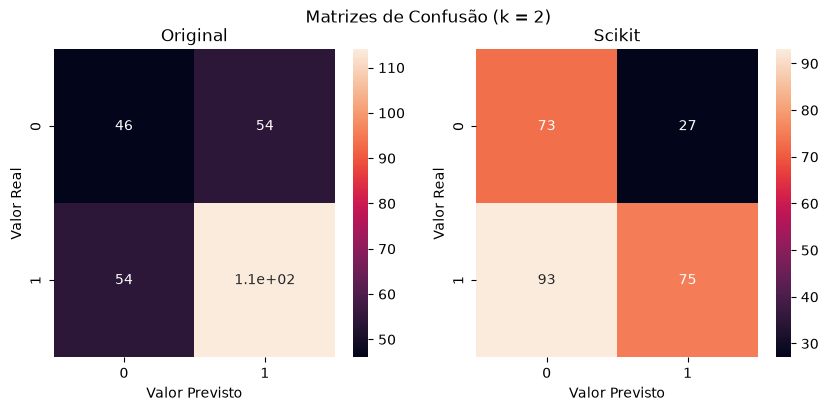


-----------------------------
(KNN) k atual: 10
-----------------------------

KNN feito em 8.63 segundos!


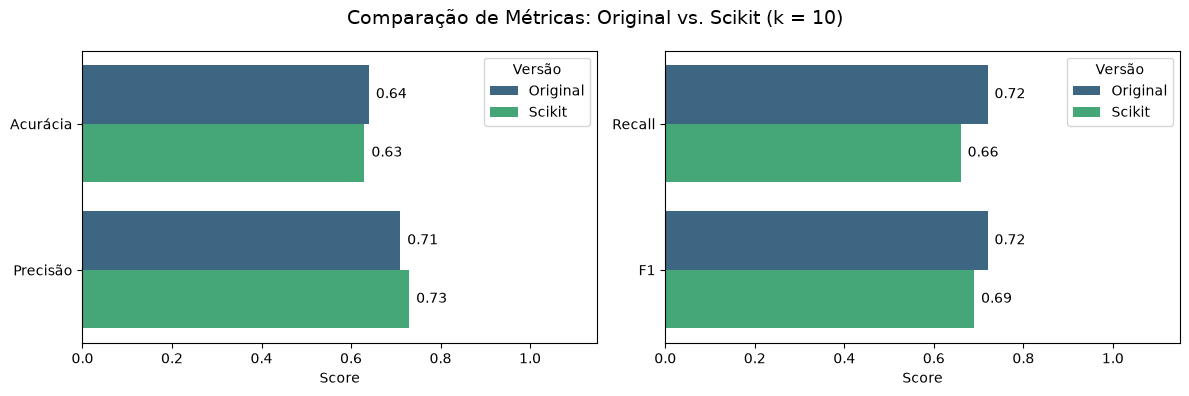

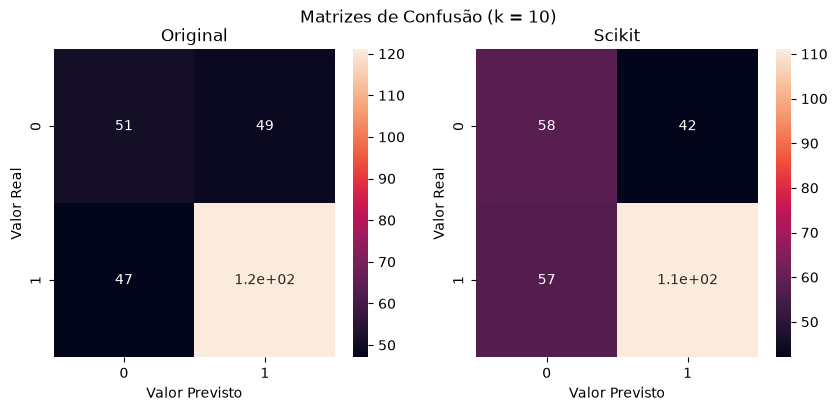


-----------------------------
(KNN) k atual: 50
-----------------------------

KNN feito em 3.63 segundos!


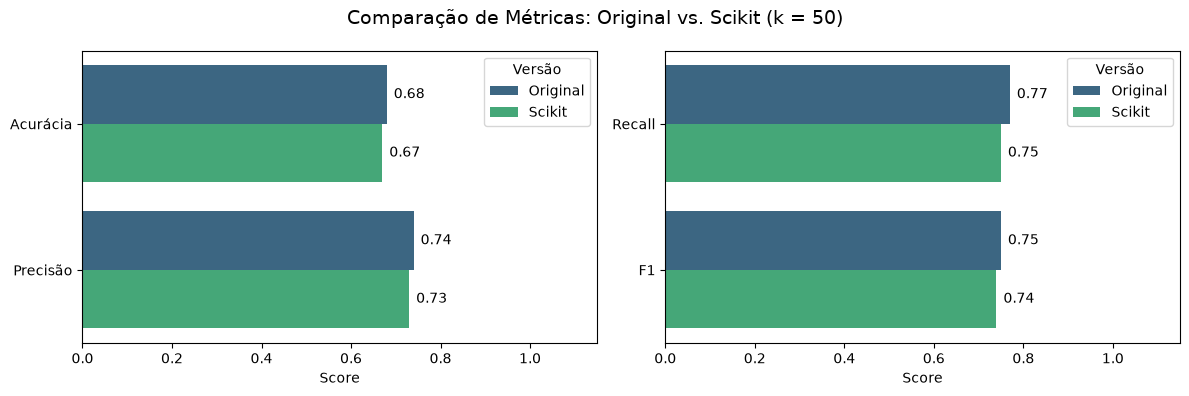

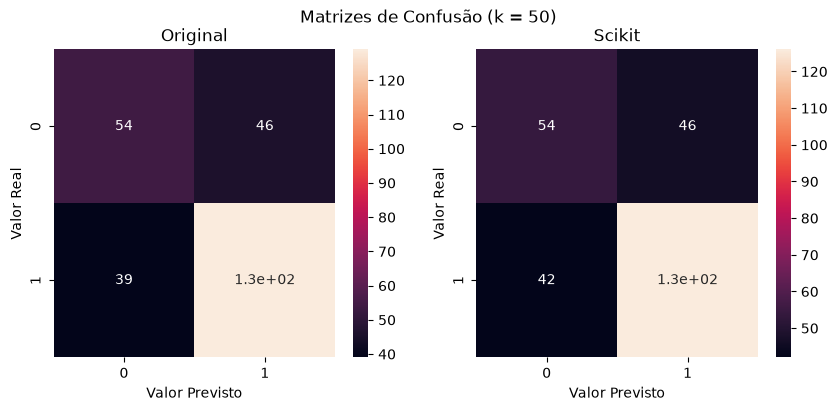


-----------------------------
(KNN) k atual: 100
-----------------------------

KNN feito em 3.64 segundos!


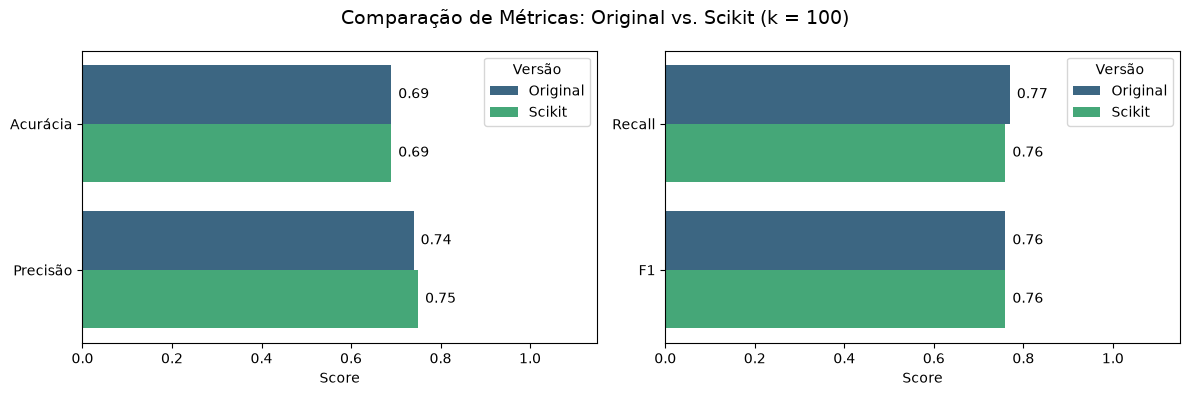

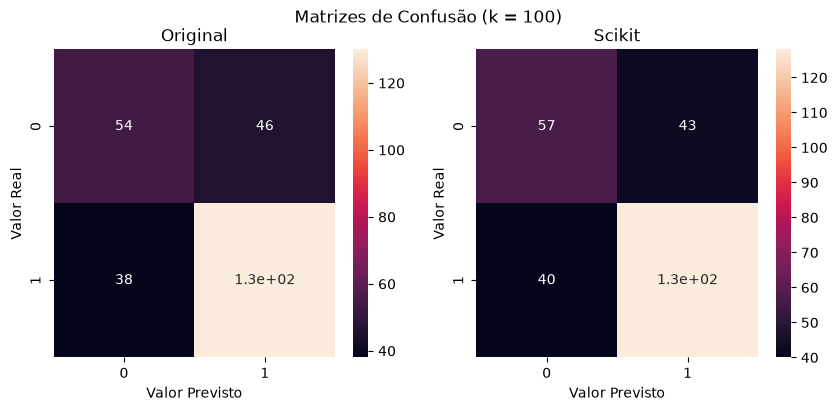

In [4]:
for k in [2, 10, 50, 100]:
    print(f"\n-----------------------------\n(KNN) k atual: {k}\n-----------------------------\n")

    predictions_knn_original = knn_dataset(X_train, y_train, X_test, k)

    knn_scikit = KNeighborsClassifier(n_neighbors=k).fit(X_train, y_train)
    predictions_knn_scikit = knn_scikit.predict(X_test)

    plot_knn_scores(y_test, predictions_knn_original, predictions_knn_scikit, k)


# K-Means

## Definições de Função

In [5]:
def nearest_centroid_label(centroids, point):
    distances = [euclidian_distance(centroid, point) for centroid in centroids]

    return np.argmin(distances) # o índice do centroide mais próximo

def kmeans_dataset(df, k, max_iter=300, tol=1e-4):
    start = time.time()
    
    X = df.to_numpy()
    n_samples, n_features = X.shape
    
    np.random.seed(413)
    random_indices = np.random.choice(n_samples, k, replace=False)
    centroids = X[random_indices]
    
    labels = np.zeros(n_samples)
    
    for iteration in range(max_iter):
        new_labels = np.array([nearest_centroid_label(centroids, point) for point in X])
        new_centroids = np.zeros((k, n_features))

        for cluster_idx in range(k):
            cluster_points = X[new_labels == cluster_idx]
            
            # se um cluster ficar vazio, mantém o centroide antigo
            if len(cluster_points) > 0:
                new_centroids[cluster_idx] = cluster_points.mean(axis=0)
            else:
                new_centroids[cluster_idx] = centroids[cluster_idx]
        
        # verifica se os centroides mudaram significativamente
        centroid_shift = np.sum((new_centroids - centroids) ** 2)
        centroids = new_centroids
        labels = new_labels
        
        if centroid_shift < tol:
            break
            
    end = time.time()
    time_elapsed = round(end - start, 2)
    print(f"K-Means feito em {time_elapsed} segundos!")
    
    return labels, centroids

def compute_inertia(df, labels, centroids):
    X = df.to_numpy()
    inertia = 0
    for i, point in enumerate(X):
        centroid = centroids[int(labels[i])]
        inertia += euclidian_distance(centroid, point) ** 2
    return round(inertia, 2)

def print_centroids (centroids, feature_names):
    for idx, centroid in enumerate(centroids):
        print(f"\n\tCentroide do Cluster {idx}:")

        for feat, val in zip(feature_names, centroid):
            print(f"\t\t- {feat}: {val:.4f}")
    print("\n" + "-"*40)

def plot_kmeans_inertia(k, inertia_original, inertia_scikit):
    data_list = [
        {
            "Versão": "Original",
            "Inércia": inertia_original,
        },
        {
            "Versão": "Scikit",
            "Inércia": inertia_scikit,
        }
    ]

    df_metrics = pd.DataFrame(data_list)
    fig, ax = plt.subplots(figsize=(8, 3.5))

    sns.barplot(
        data=df_metrics, x="Inércia", y="Versão", hue="Versão", ax=ax, orient="h", legend=False, palette='viridis'
    )
    ax.set_xlabel("Inércia")
    ax.set_ylabel("")
    
    # margem no eixo X pros números não ficarem cortados
    max_inertia = max(inertia_original, inertia_scikit)
    ax.set_xlim(0, max_inertia * 1.15)

    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", padding=5)

    fig.suptitle(f"Comparação de Inércia (k = {k}): Original vs Scikit", fontsize=12)
    plt.tight_layout()
    
    plt.savefig(f"plots/kmeans_inertia_k_{k}.png")
    plt.show()

def plot_kmeans_clusters_comparison(k, labels_orig, labels_sk, y_real):
    df_plot = pd.DataFrame({
        'Cluster_Original': labels_orig,
        'Cluster_Scikit': labels_sk,
        'Atingiu_5_Anos': y_real.map({1: 'Sim', 0: 'Não'}) # Mapeia para ficar legível no gráfico
    })
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    
    sns.countplot(
        data=df_plot, 
        x='Cluster_Original', 
        hue='Atingiu_5_Anos', 
        ax=axes[0], 
        palette='viridis'
    )
    axes[0].set_title('K-Means Original', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Clusters')
    axes[0].set_ylabel('Quantidade de Jogadores')
    axes[0].legend(title='Atingiu 5 Anos?')
    axes[0].grid(axis='y', linestyle='--', alpha=0.7)
    
    for container in axes[0].containers:
        axes[0].bar_label(container, fmt='%d', padding=3)
        
    sns.countplot(
        data=df_plot, 
        x='Cluster_Scikit', 
        hue='Atingiu_5_Anos', 
        ax=axes[1], 
        palette='viridis'
    )
    axes[1].set_title('K-Means Scikit-Learn', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Clusters')
    axes[1].set_ylabel('') # oculta o eixo Y compartilhado pra não poluir
    axes[1].legend(title='Atingiu 5 Anos?')
    axes[1].grid(axis='y', linestyle='--', alpha=0.7)
    
    for container in axes[1].containers:
        axes[1].bar_label(container, fmt='%d', padding=3)

    fig.suptitle(f'Distribuição de Jogadores por Cluster e Target (k = {k})', fontsize=14, y=1.02)
    plt.tight_layout()
    
    plt.savefig(f"plots/kmeans_target_distribution_k_{k}.png", bbox_inches='tight')
    plt.show()

## Previsão e estatísticas


-----------------------------
(K-Means) k atual: 2
-----------------------------

K-Means feito em 0.18 segundos!
Centroides Obtidos (K-Means Original para k=2)

	Centroide do Cluster 0:
		- GP: 73.9475
		- MIN: 22.4613
		- PTS: 9.1011
		- FGM: 3.5170
		- FGA: 7.7482
		- FG%: 45.3330
		- 3PMade: 0.3236
		- 3PA: 0.9903
		- 3P%: 21.4062
		- FTM: 1.7460
		- FTA: 2.4052
		- FT%: 72.6478
		- OREB: 1.2695
		- DREB: 2.6064
		- REB: 3.8756
		- AST: 2.0941
		- STL: 0.7972
		- BLK: 0.4673
		- TOV: 1.5483

	Centroide do Cluster 1:
		- GP: 44.5081
		- MIN: 11.9399
		- PTS: 4.0987
		- FGM: 1.5856
		- FGA: 3.6958
		- FG%: 42.8018
		- 3PMade: 0.1583
		- 3PA: 0.5310
		- 3P%: 16.4974
		- FTM: 0.7708
		- FTA: 1.1364
		- FT%: 67.5412
		- OREB: 0.7037
		- DREB: 1.3433
		- REB: 2.0459
		- AST: 0.9117
		- STL: 0.4084
		- BLK: 0.2526
		- TOV: 0.7766

----------------------------------------
Centroides Obtidos (K-Means Scikit para k=2)

	Centroide do Cluster 0:
		- GP: 73.9475
		- MIN: 22.4613
		- PTS: 9.101

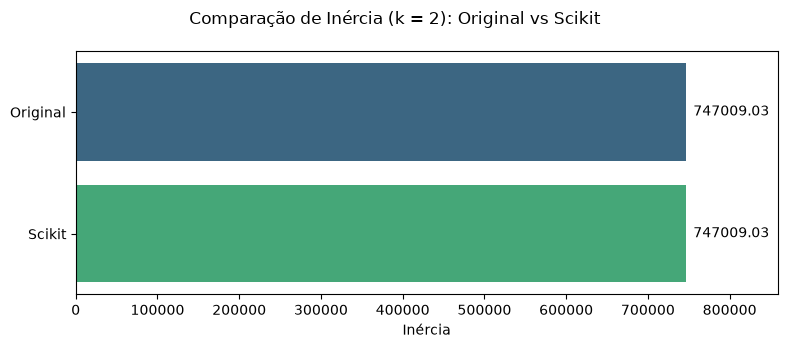

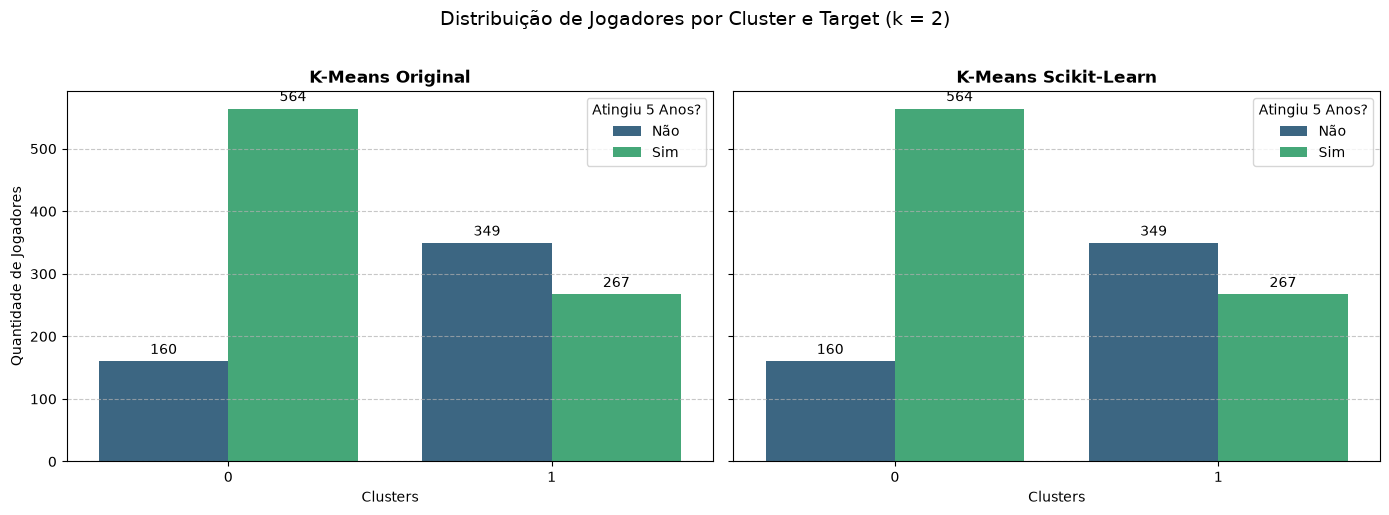


-----------------------------
(K-Means) k atual: 3
-----------------------------

K-Means feito em 0.42 segundos!
Centroides Obtidos (K-Means Original para k=3)

	Centroide do Cluster 0:
		- GP: 61.7479
		- MIN: 15.8513
		- PTS: 5.9654
		- FGM: 2.3684
		- FGA: 4.8844
		- FG%: 47.9333
		- 3PMade: 0.0009
		- 3PA: 0.0476
		- 3P%: 1.0165
		- FTM: 1.2271
		- FTA: 1.8564
		- FT%: 65.3872
		- OREB: 1.3340
		- DREB: 2.3017
		- REB: 3.6368
		- AST: 0.9107
		- STL: 0.4808
		- BLK: 0.5329
		- TOV: 1.0551

	Centroide do Cluster 1:
		- GP: 40.8780
		- MIN: 12.4260
		- PTS: 4.2321
		- FGM: 1.6013
		- FGA: 3.9554
		- FG%: 40.0623
		- 3PMade: 0.2690
		- 3PA: 0.8729
		- 3P%: 27.0809
		- FTM: 0.7618
		- FTA: 1.0676
		- FT%: 70.3833
		- OREB: 0.5361
		- DREB: 1.1918
		- REB: 1.7241
		- AST: 1.1491
		- STL: 0.4565
		- BLK: 0.1708
		- TOV: 0.8151

	Centroide do Cluster 2:
		- GP: 74.0323
		- MIN: 23.2606
		- PTS: 9.5489
		- FGM: 3.6584
		- FGA: 8.3014
		- FG%: 43.7388
		- 3PMade: 0.4646
		- 3PA: 1.3994
		

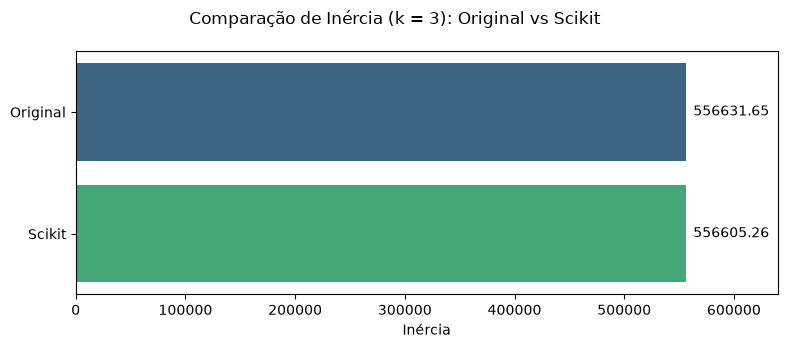

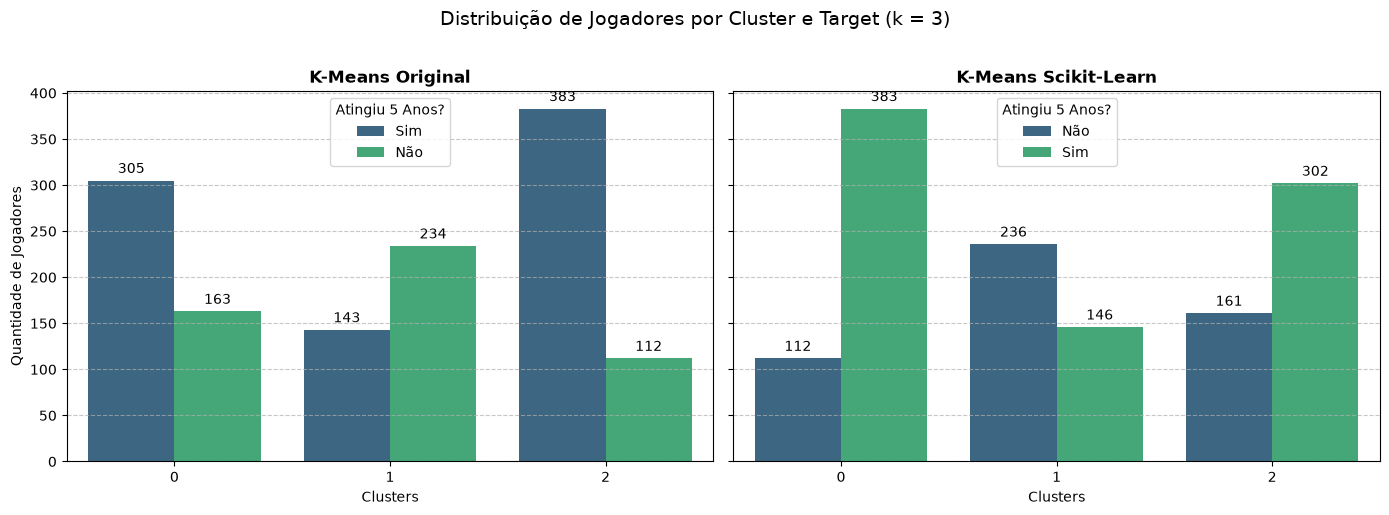

In [6]:
df_kmeans = pd.concat([X_train, X_test]).reset_index(drop=True)
y_original = pd.concat([y_train, y_test]).reset_index(drop=True)

feature_names = df_kmeans.columns.tolist()

for k in [2, 3]:
    print(f"\n-----------------------------\n(K-Means) k atual: {k}\n-----------------------------\n")
    
    labels_original, centroids_original = kmeans_dataset(df_kmeans, k)
    inertia_original = compute_inertia(df_kmeans, labels_original, centroids_original)
    
    kmeans_scikit = KMeans(n_clusters=k, init='random', n_init=1, random_state=42, max_iter=300)
    kmeans_scikit.fit(df_kmeans)

    labels_scikit = kmeans_scikit.labels_
    inertia_scikit = round(kmeans_scikit.inertia_, 2)
    centroids_scikit = kmeans_scikit.cluster_centers_
    
    print(f"Centroides Obtidos (K-Means Original para k={k})")
    print_centroids(centroids_original, feature_names)
    
    print(f"Centroides Obtidos (K-Means Scikit para k={k})")
    print_centroids(centroids_scikit, feature_names)

    plot_kmeans_inertia(k, inertia_original, inertia_scikit)
    plot_kmeans_clusters_comparison(k, labels_original, labels_scikit, y_original)